In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
# import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

# import scienceplots
# plt.style.use('science')
sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [3]:
# color palette(s)
dual = ['#B9529F','gray']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']
triple = ['gray', 'Tab:blue','Tab:red']
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:blue', 'Tab:red', 'Tab:red', 'gray', 'gray']

# Define functions

In [4]:
def preprocess_plot(df, name, plotting = True):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        # _, p = stats.ttest_ind(df[(df['Behaviour_6hFD'] == 'Pre')][column].dropna(),
        #                             df[df['Behaviour_6hFD'] == 'Post'][column].dropna(),
        #                             equal_var = True)
        else:
            param_df = df
        
        try:
            unique_cat = df.Behaviour_6hFD.unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:

                _, p = stats.mannwhitneyu(param_df[(param_df.Behaviour_6hFD == combo[0])][column].dropna(),
                                        param_df[(param_df.Behaviour_6hFD == combo[1])][column].dropna())
            
                print(column, combo, p)

           
        except ValueError:
            
            continue

        if plotting:
            try:
                
                fig,ax = plt.subplots(figsize = (3,3))
            
                sns.swarmplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], alpha = 1, size = 3)
                sns.boxplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], boxprops=dict(alpha=0.7), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# Ephys analysis - panMPOA

In [5]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD =='Agg+','Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

gal = df[df.Gal_positive == 'yes']
no_gal = df[df.Gal_positive == 'no']
ephys = df[df.Gal_positive.isin(['Unknown', 'no'])]
ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD.isin(cat)]])
sample_num= int(no_gal.shape[0]/4)
ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 859)]).reset_index(drop = True)

ephys.to_csv('sampled_ephys_data.csv')

In [55]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

## All properties

Cm(pF) ('Pre', 'Agg+') 0.11417856564152562
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.001141834338445008
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.07867552696413699
Firing_freq_(Hz)_I0 ('Pre', 'npy_antag') 0.09606561196772205
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.0007970795143110371
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.0002981265264105751
Firing_freq_(Hz)_I0 ('Agg+', 'npy_antag') 0.0006941280477823437
Firing_freq_(Hz)_I0 ('Agg+', 'ZD7288') 0.09856392453955692
Firing_freq_(Hz)_I0 ('Agg-', 'npy_antag') 1.0
Firing_freq_(Hz)_I0 ('Agg-', 'ZD7288') 0.0007718608499895493
Firing_freq_(Hz)_I0 ('npy_antag', 'ZD7288') 0.0010206517764102872


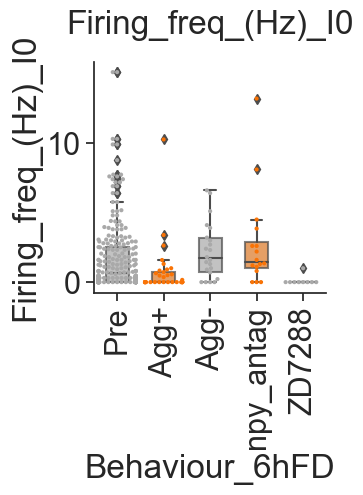

Instant_freq_(Hz) ('Pre', 'Agg+') 0.0007367704239688566
Instant_freq_(Hz) ('Pre', 'Agg-') 0.19193653707787806
Instant_freq_(Hz) ('Pre', 'npy_antag') 0.13469792264704594
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.001097363686856712
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0007405872797472339
Instant_freq_(Hz) ('Agg+', 'npy_antag') 0.0010251997337301646
Instant_freq_(Hz) ('Agg+', 'ZD7288') 0.10949295754110173
Instant_freq_(Hz) ('Agg-', 'npy_antag') 0.6887744766798736
Instant_freq_(Hz) ('Agg-', 'ZD7288') 0.0018326276980825283
Instant_freq_(Hz) ('npy_antag', 'ZD7288') 0.0028003326500912855


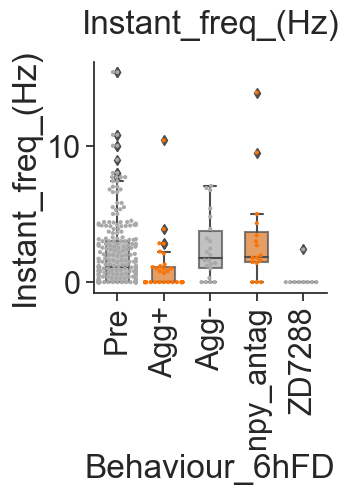

isi_(ms) ('Pre', 'Agg+') 0.5443070459729777
isi_(ms) ('Pre', 'Agg-') 0.07456403194442299
isi_(ms) ('Pre', 'npy_antag') 0.069441273846096
isi_(ms) ('Pre', 'ZD7288') 0.834151226836059
isi_(ms) ('Agg+', 'Agg-') 0.014668259625073753
isi_(ms) ('Agg+', 'npy_antag') 0.011289948137763824
isi_(ms) ('Agg+', 'ZD7288') 0.75
isi_(ms) ('Agg-', 'npy_antag') 1.0
isi_(ms) ('Agg-', 'ZD7288') 0.42105263157894735
isi_(ms) ('npy_antag', 'ZD7288') 0.2857142857142857


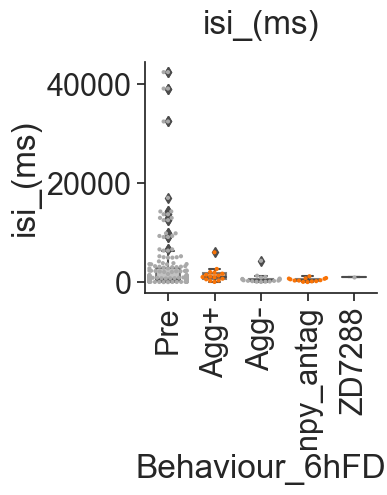

CaT ('Pre', 'Agg+') 0.30049066112363987
CaT ('Pre', 'Agg-') 0.6163362596118752
CaT ('Pre', 'npy_antag') 0.007292955309225689
CaT ('Pre', 'ZD7288') 0.5615171272490018
CaT ('Agg+', 'Agg-') 0.2071794724388344
CaT ('Agg+', 'npy_antag') 0.06458735385751317
CaT ('Agg+', 'ZD7288') 0.9379573336186529
CaT ('Agg-', 'npy_antag') 0.003931613053118365
CaT ('Agg-', 'ZD7288') 0.4969394928289175
CaT ('npy_antag', 'ZD7288') 0.08106185559577476


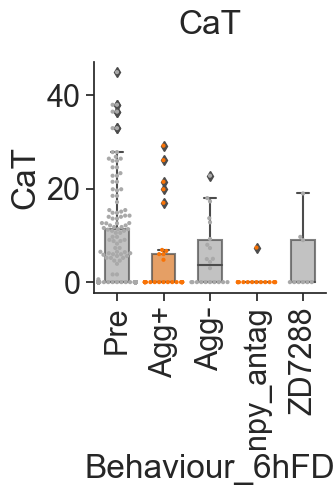

Ih_at_-120mV ('Pre', 'Agg+') 0.02340910483229194
Ih_at_-120mV ('Pre', 'Agg-') 0.3699112868110501
Ih_at_-120mV ('Pre', 'npy_antag') 0.1898370198603837
Ih_at_-120mV ('Pre', 'ZD7288') 0.0002298653289189648
Ih_at_-120mV ('Agg+', 'Agg-') 0.00265638281465584
Ih_at_-120mV ('Agg+', 'npy_antag') 0.5935780616453017
Ih_at_-120mV ('Agg+', 'ZD7288') 0.002448378076647571
Ih_at_-120mV ('Agg-', 'npy_antag') 0.02583179872478611
Ih_at_-120mV ('Agg-', 'ZD7288') 3.1739315352409464e-05
Ih_at_-120mV ('npy_antag', 'ZD7288') 0.0006497191701663903


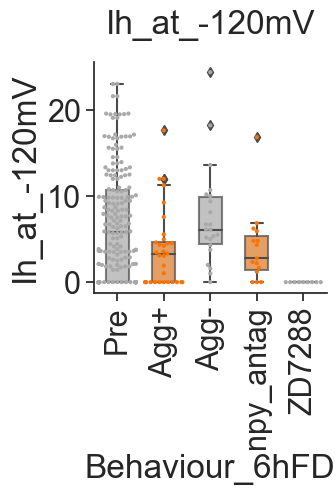

AP_ampl ('Pre', 'Agg+') 0.44699683638719157
AP_ampl ('Pre', 'Agg-') 0.8604299205678079
AP_ampl ('Pre', 'npy_antag') 0.09716453533879316
AP_ampl ('Pre', 'ZD7288') 0.7153518609207287
AP_ampl ('Agg+', 'Agg-') 0.7585816773946292
AP_ampl ('Agg+', 'npy_antag') 0.6450020249878708
AP_ampl ('Agg+', 'ZD7288') 1.0
AP_ampl ('Agg-', 'npy_antag') 0.22971930286732778
AP_ampl ('Agg-', 'ZD7288') 0.8421052631578947
AP_ampl ('npy_antag', 'ZD7288') 0.857142857142857


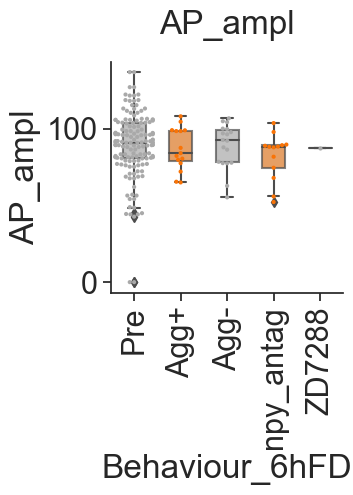

AP_halfwidth ('Pre', 'Agg+') 0.7688932272453011
AP_halfwidth ('Pre', 'Agg-') 0.0092114640019038
AP_halfwidth ('Pre', 'npy_antag') 0.052839346148121545
AP_halfwidth ('Pre', 'ZD7288') 0.6113291410660702
AP_halfwidth ('Agg+', 'Agg-') 0.04087328572937924
AP_halfwidth ('Agg+', 'npy_antag') 0.09710902769459956
AP_halfwidth ('Agg+', 'ZD7288') 0.875
AP_halfwidth ('Agg-', 'npy_antag') 0.9042339179186766
AP_halfwidth ('Agg-', 'ZD7288') 0.6473550172983791
AP_halfwidth ('npy_antag', 'ZD7288') 1.0


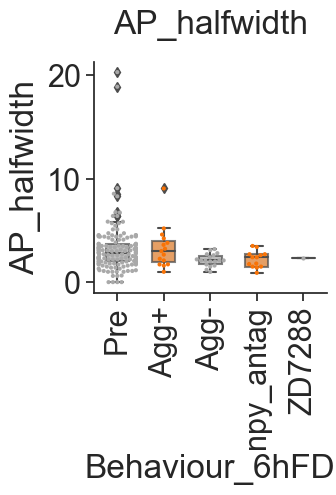

AP_time_to_peak ('Pre', 'Agg+') 0.2018485137695405
AP_time_to_peak ('Pre', 'Agg-') 0.3546817887359629
AP_time_to_peak ('Pre', 'npy_antag') 0.6632004725129065
AP_time_to_peak ('Pre', 'ZD7288') 0.4248038335910779
AP_time_to_peak ('Agg+', 'Agg-') 0.46913433639048585
AP_time_to_peak ('Agg+', 'npy_antag') 0.39357984003304725
AP_time_to_peak ('Agg+', 'ZD7288') 1.0
AP_time_to_peak ('Agg-', 'npy_antag') 0.7177584267032746
AP_time_to_peak ('Agg-', 'ZD7288') 0.40904435007858275
AP_time_to_peak ('npy_antag', 'ZD7288') 0.38157390570502137


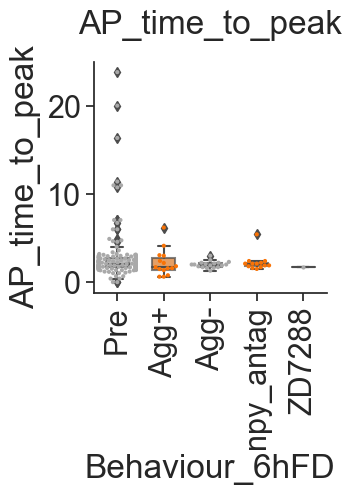

area(mV_ms) ('Pre', 'Agg+') 0.5080671430720511
area(mV_ms) ('Pre', 'Agg-') 0.002661745250367503
area(mV_ms) ('Pre', 'npy_antag') 0.02721957396305897
area(mV_ms) ('Pre', 'ZD7288') 0.45196621592143627
area(mV_ms) ('Agg+', 'Agg-') 0.3027726388020737
area(mV_ms) ('Agg+', 'npy_antag') 0.3930812075577269
area(mV_ms) ('Agg+', 'ZD7288') 1.0
area(mV_ms) ('Agg-', 'npy_antag') 1.0
area(mV_ms) ('Agg-', 'ZD7288') 1.0
area(mV_ms) ('npy_antag', 'ZD7288') 1.0


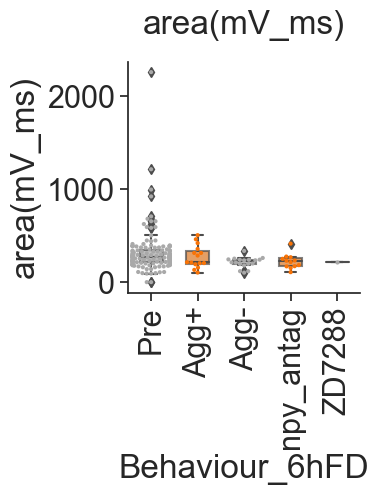

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.030818404421841444
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.0681455319408518
rheobase_at_-60mV_(pA) ('Pre', 'npy_antag') 0.11065853469684687
rheobase_at_-60mV_(pA) ('Pre', 'ZD7288') 0.031165366244469028
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.7915786312985644
rheobase_at_-60mV_(pA) ('Agg+', 'npy_antag') 0.5375428800113841
rheobase_at_-60mV_(pA) ('Agg+', 'ZD7288') 0.005784715791354898
rheobase_at_-60mV_(pA) ('Agg-', 'npy_antag') 0.909547553182925
rheobase_at_-60mV_(pA) ('Agg-', 'ZD7288') 0.01342158738742916
rheobase_at_-60mV_(pA) ('npy_antag', 'ZD7288') 0.020142478282843237


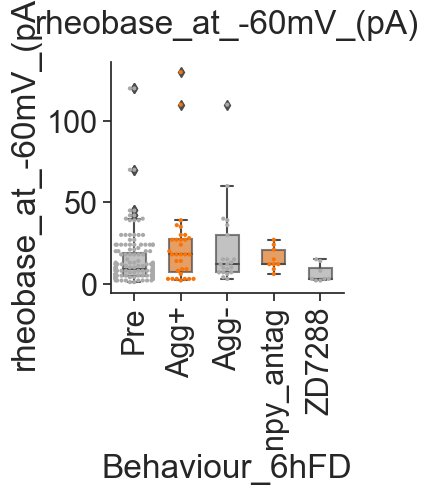

AHP_(mV) ('Pre', 'Agg+') 0.6358489967429953
AHP_(mV) ('Pre', 'Agg-') 0.9938230372144568
AHP_(mV) ('Pre', 'npy_antag') 0.3254015182240797
AHP_(mV) ('Pre', 'ZD7288') 0.8534028758268617
AHP_(mV) ('Agg+', 'Agg-') 0.5751721848393921
AHP_(mV) ('Agg+', 'npy_antag') 0.8537292325872324
AHP_(mV) ('Agg+', 'ZD7288') 0.5148719362740404
AHP_(mV) ('Agg-', 'npy_antag') 0.42329289813043247
AHP_(mV) ('Agg-', 'ZD7288') 0.8421052631578947
AHP_(mV) ('npy_antag', 'ZD7288') 0.7142857142857142


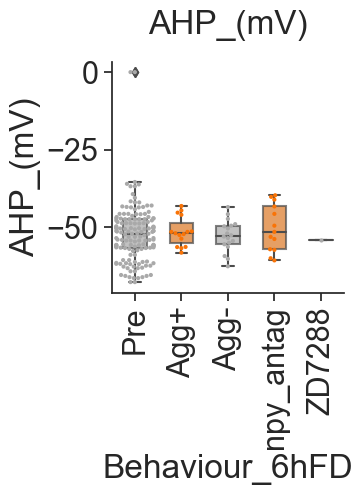

Vm ('Pre', 'Agg+') 0.8982707250780338
Vm ('Pre', 'Agg-') 0.6743590730123553
Vm ('Pre', 'npy_antag') 0.07680105431321806
Vm ('Pre', 'ZD7288') 0.06639721680312931
Vm ('Agg+', 'Agg-') 0.8866037069455793
Vm ('Agg+', 'npy_antag') 0.18661555466497703
Vm ('Agg+', 'ZD7288') 0.15615516528732576
Vm ('Agg-', 'npy_antag') 0.2428705103125236
Vm ('Agg-', 'ZD7288') 0.1572500789959627
Vm ('npy_antag', 'ZD7288') 0.6711254583898127


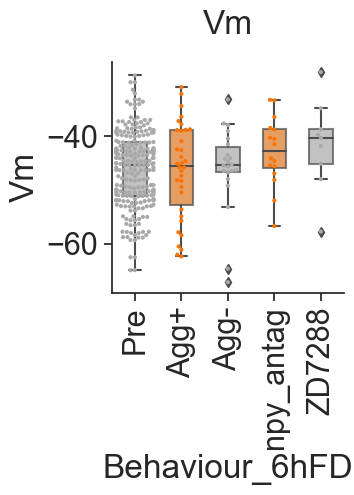

Input_Resistance ('Pre', 'Agg+') 0.03338009925029897
Input_Resistance ('Pre', 'Agg-') 0.4196098840605077
Input_Resistance ('Pre', 'npy_antag') 0.5945026695137088
Input_Resistance ('Pre', 'ZD7288') 0.0034776154225607155
Input_Resistance ('Agg+', 'Agg-') 0.05173515538984456
Input_Resistance ('Agg+', 'npy_antag') 0.3580277263050924
Input_Resistance ('Agg+', 'ZD7288') 0.08604068794211162
Input_Resistance ('Agg-', 'npy_antag') 0.40796820839232995
Input_Resistance ('Agg-', 'ZD7288') 0.0021541104518153133
Input_Resistance ('npy_antag', 'ZD7288') 0.03483238234691384


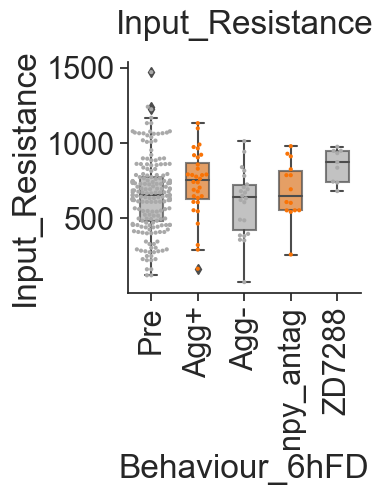

sPSC_frequency ('Pre', 'Agg+') 0.7665681084326172
sPSC_frequency ('Pre', 'Agg-') 0.4616945699435895
sPSC_frequency ('Pre', 'npy_antag') 0.2571466057451488
sPSC_frequency ('Pre', 'ZD7288') 0.0004449077665014611
sPSC_frequency ('Agg+', 'Agg-') 0.436189444791807
sPSC_frequency ('Agg+', 'npy_antag') 0.24425409398682496
sPSC_frequency ('Agg+', 'ZD7288') 0.0012361034761739548
sPSC_frequency ('Agg-', 'npy_antag') 0.4864136413391559
sPSC_frequency ('Agg-', 'ZD7288') 0.0016887282854299345
sPSC_frequency ('npy_antag', 'ZD7288') 0.019412050237194937


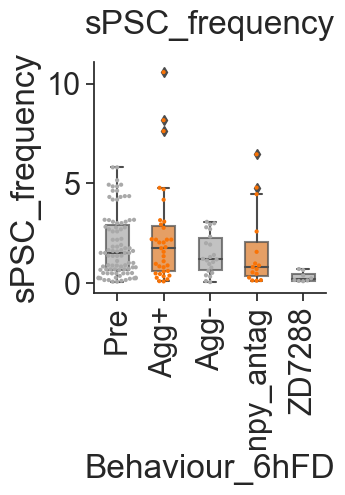

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.5636684552008127
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.009324784187781958
sPSC_Amplitude(pA) ('Pre', 'npy_antag') 0.15465528233354042
sPSC_Amplitude(pA) ('Pre', 'ZD7288') 0.0011335141620435678
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.048158234139899926
sPSC_Amplitude(pA) ('Agg+', 'npy_antag') 0.06394339015998485
sPSC_Amplitude(pA) ('Agg+', 'ZD7288') 0.003182782800393876
sPSC_Amplitude(pA) ('Agg-', 'npy_antag') 0.0077400902969120035
sPSC_Amplitude(pA) ('Agg-', 'ZD7288') 0.013642787090909672
sPSC_Amplitude(pA) ('npy_antag', 'ZD7288') 0.00604374428418259


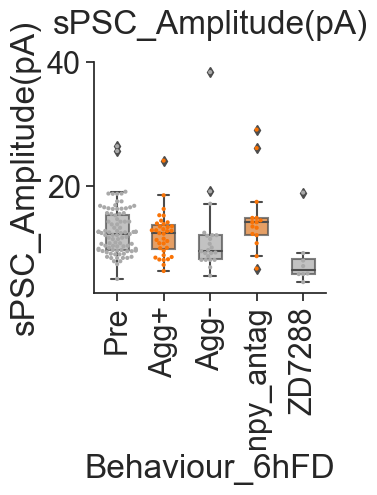

sPSCs_Rise time ('Pre', 'Agg+') 0.5670220576469902
sPSCs_Rise time ('Pre', 'Agg-') 0.33910576724256336
sPSCs_Rise time ('Pre', 'npy_antag') 0.000469000604710787
sPSCs_Rise time ('Pre', 'ZD7288') 0.5104898916905982
sPSCs_Rise time ('Agg+', 'Agg-') 0.2519570880816514
sPSCs_Rise time ('Agg+', 'npy_antag') 0.0006506322665170589
sPSCs_Rise time ('Agg+', 'ZD7288') 0.741829264903328
sPSCs_Rise time ('Agg-', 'npy_antag') 0.07658989201337563
sPSCs_Rise time ('Agg-', 'ZD7288') 0.620780270779305
sPSCs_Rise time ('npy_antag', 'ZD7288') 0.10821649327317735


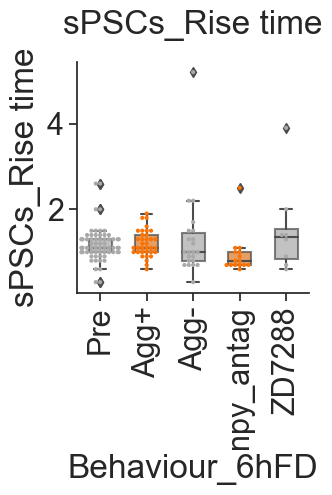

sPSCs (decay) ('Pre', 'Agg+') 0.35440443921531484
sPSCs (decay) ('Pre', 'Agg-') 0.5374371881981251
sPSCs (decay) ('Pre', 'npy_antag') 0.22275882047574624
sPSCs (decay) ('Pre', 'ZD7288') 0.30265326527549163
sPSCs (decay) ('Agg+', 'Agg-') 0.9932478186992534
sPSCs (decay) ('Agg+', 'npy_antag') 0.12478623903013916
sPSCs (decay) ('Agg+', 'ZD7288') 0.2815854533487766
sPSCs (decay) ('Agg-', 'npy_antag') 0.1531914880521656
sPSCs (decay) ('Agg-', 'ZD7288') 0.3536940897929446
sPSCs (decay) ('npy_antag', 'ZD7288') 0.9484561673937018


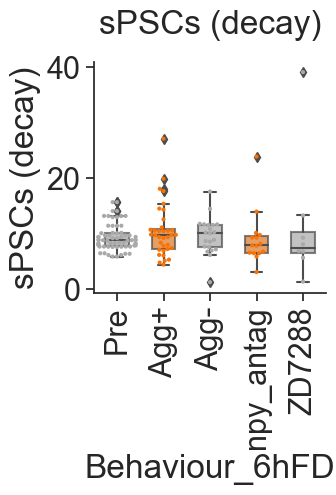

In [46]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'ZD7288']
preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)], 'pan')

## Individual plots - panMPOA

In [7]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+')]

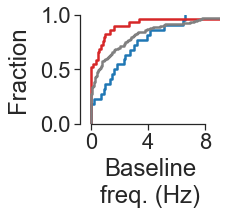

In [8]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple_ff, linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [9]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+') |
                      (ephys['Behaviour_6hFD'] == 'npy_antag') | (ephys['Behaviour_6hFD'] == 'npy_KD_dummy') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

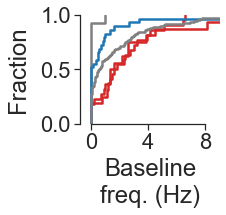

In [10]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_all, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = sixtus, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [11]:
# len(ephys[ephys[('Behaviour_6hFD') == 'Pre']].Vm)

len(ephys[(ephys['Behaviour_6hFD'] == 'Pre')].Vm)

# df[(df['projection_site'] == 'pan') & (df['state'] == 'D10')]

246

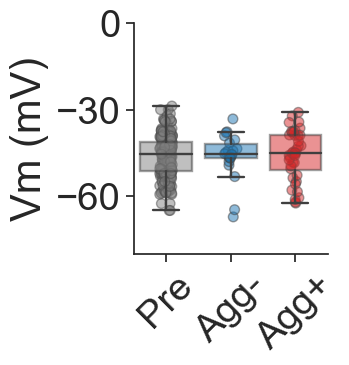

In [9]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order = ['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [1]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = sixtus)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order = ['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = sixtus, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+', 'AntY', 'Y-KD', 'ZD'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

NameError: name 'sns' is not defined

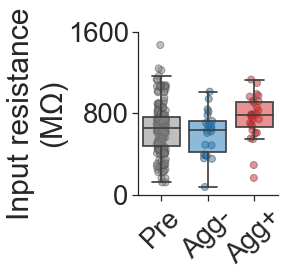

In [14]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Input resistance\n(MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

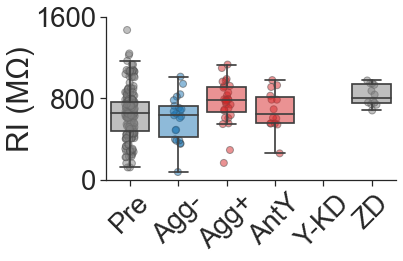

In [15]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = sixtus)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = sixtus, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+', 'AntY', 'Y-KD', 'ZD'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

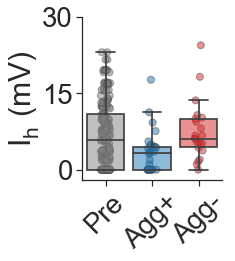

In [16]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

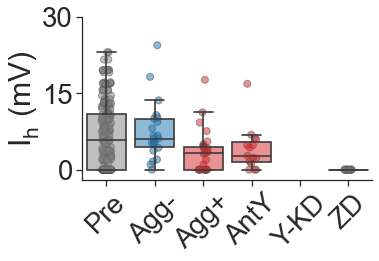

In [17]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = sixtus)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = sixtus, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+', 'AntY', 'Y-KD', 'ZD'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [18]:
ephys.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm(pF)', 'Adaptive',
       'I_zero', 'I_zero_reclassified', '60mV', 'Firing_freq_(Hz)_I0',
       'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ', 'CaT', 'Ih',
       'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak',
       'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments',
       'Unnamed: 35'],
      dtype='object')

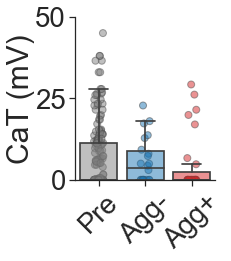

In [19]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('CaT (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+'), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

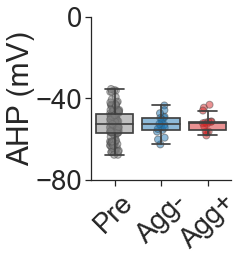

In [20]:
# AHP

ephys_filtered = ephys[ephys['AHP_(mV)'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('AHP (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg-', 'Agg+'), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

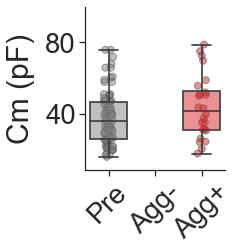

In [21]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

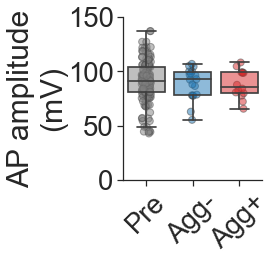

In [22]:
# AP_ampl
ephys_filt = ephys[ephys['AP_ampl'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP amplitude\n(mV)', labelpad=0)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
plt.ylim(0,150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

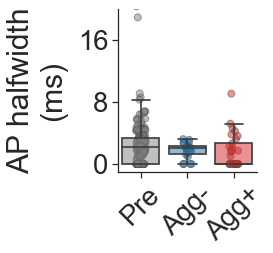

In [23]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP halfwidth\n(ms)', labelpad=10)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=20)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

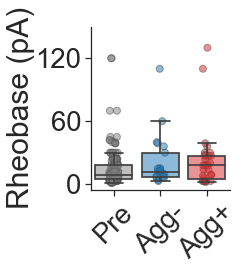

In [24]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Rheobase (pA)', labelpad=0)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

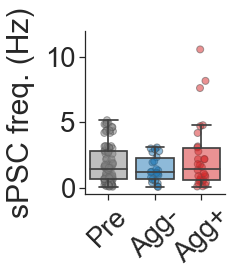

In [25]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC freq. (Hz)', labelpad=10)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=12)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

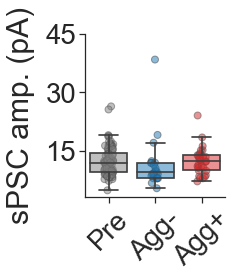

In [26]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. (pA)', labelpad=10)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

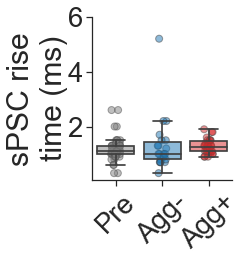

In [27]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC rise\ntime (ms)', labelpad=0)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

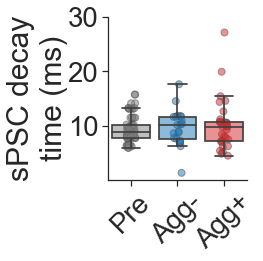

In [28]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg-', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC decay\ntime (ms)', labelpad=0)

ax.set_xticklabels(('Pre', 'Agg-','Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(top=30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

Cm(pF) ('Pre', 'Agg+') 0.568000349055369


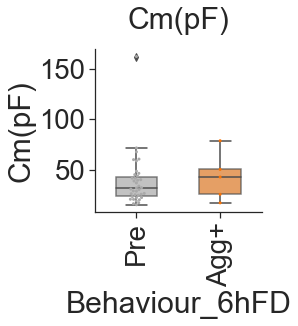

Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.28721546260366726


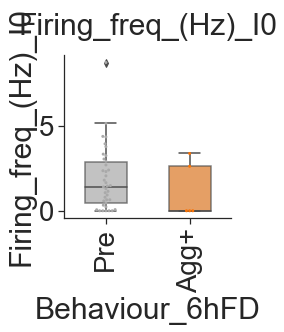

Instant_freq_(Hz) ('Pre', 'Agg+') 0.2541927698038654


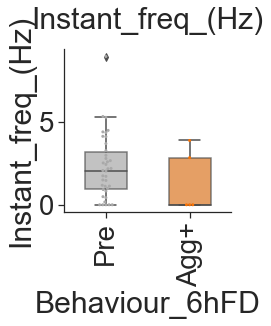

isi_(ms) ('Pre', 'Agg+') 0.3025210084033614


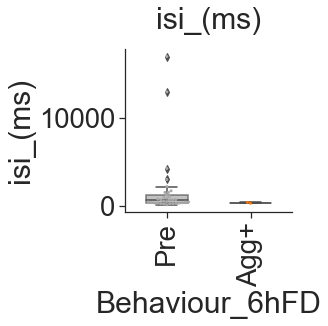

CaT ('Pre', 'Agg+') 0.09172696328617409


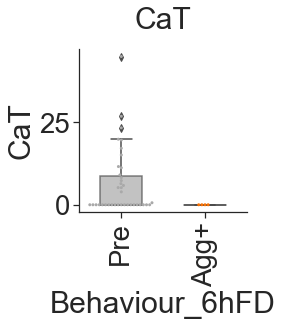

Ih_at_-120mV ('Pre', 'Agg+') 0.34655777807143007


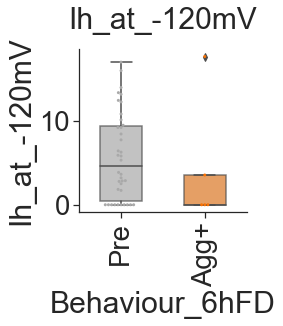

AP_ampl ('Pre', 'Agg+') 0.27062944050876925


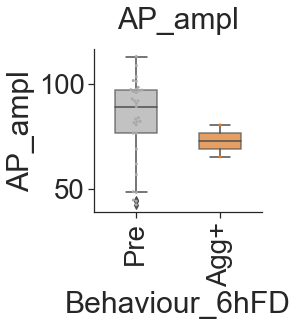

AP_halfwidth ('Pre', 'Agg+') 0.7563025210084033


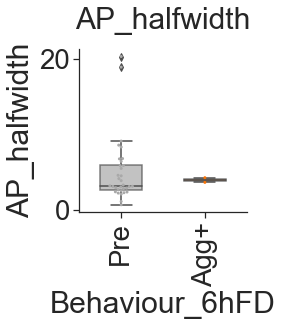

AP_time_to_peak ('Pre', 'Agg+') 0.1411764705882353


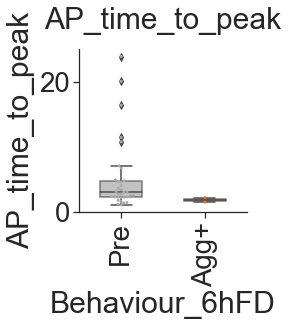

area(mV_ms) ('Pre', 'Agg+') 0.3697478991596639


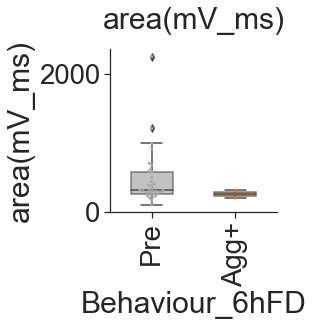

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.12860985215882415


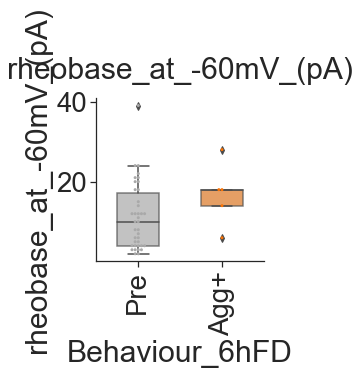

AHP_(mV) ('Pre', 'Agg+') 0.27226890756302524


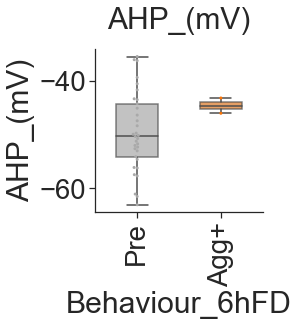

Vm ('Pre', 'Agg+') 0.568000349055369


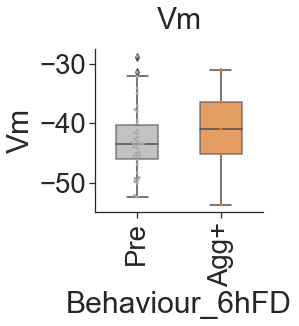

Input_Resistance ('Pre', 'Agg+') 0.9560979765177156


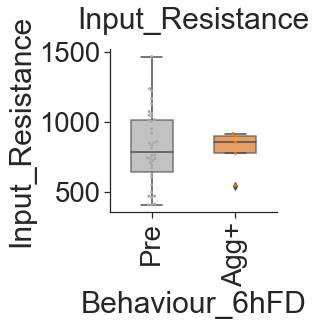

sPSC_frequency ('Pre', 'Agg+') 0.07868653086044392


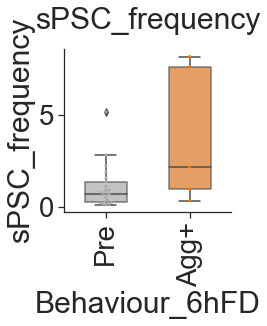

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8010337488598358


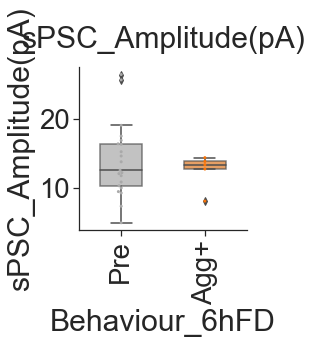

In [29]:
preprocess_plot(gal,'gal')

Cm(pF) ('Pre', 'Agg+') 0.4312064746847355


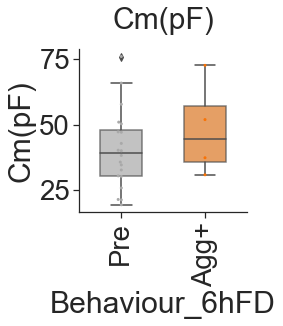

Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.4034858988262905


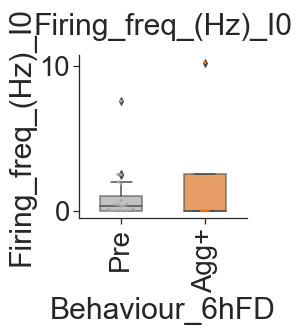

Instant_freq_(Hz) ('Pre', 'Agg+') 0.4034858988262905


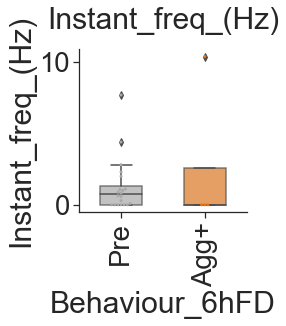

isi_(ms) ('Pre', 'Agg+') 0.13333333333333333


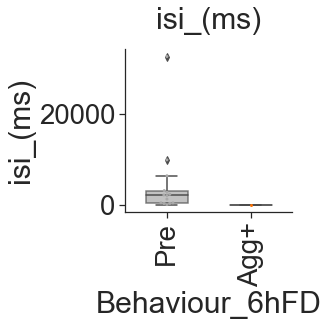

CaT ('Pre', 'Agg+') 0.18249580310381686


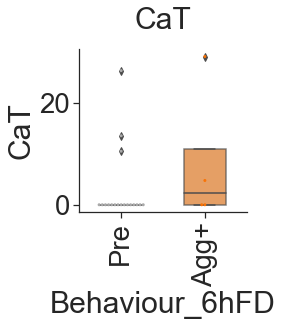

Ih_at_-120mV ('Pre', 'Agg+') 0.9339723158912411


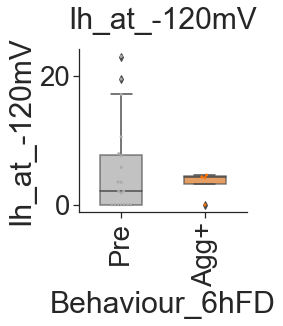

AP_ampl ('Pre', 'Agg+') 0.5333333333333333


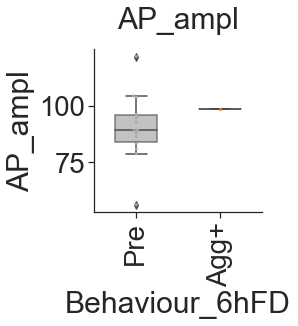

AP_halfwidth ('Pre', 'Agg+') 0.2971897434333751


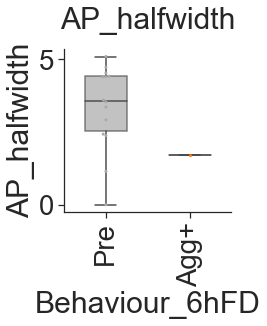

AP_time_to_peak ('Pre', 'Agg+') 0.26666666666666666


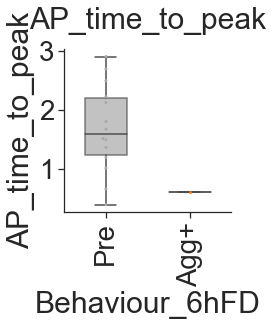

area(mV_ms) ('Pre', 'Agg+') 0.4


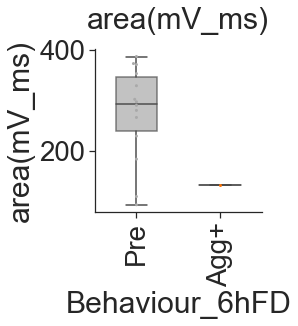

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.5152684554887583


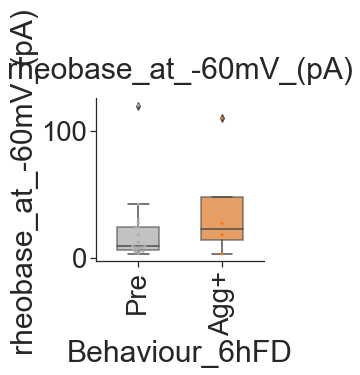

AHP_(mV) ('Pre', 'Agg+') 1.0


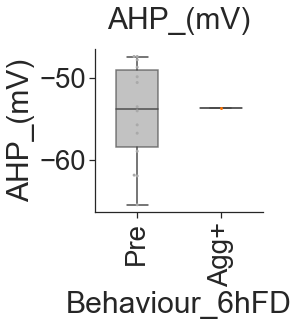

Vm ('Pre', 'Agg+') 0.08112177677395067


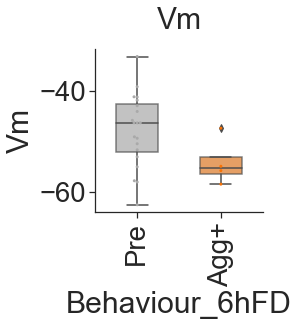

Input_Resistance ('Pre', 'Agg+') 0.9068322981366461


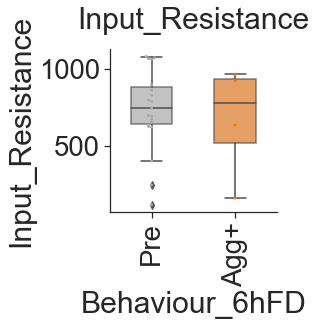

sPSC_frequency ('Pre', 'Agg+') 0.9700734048560136


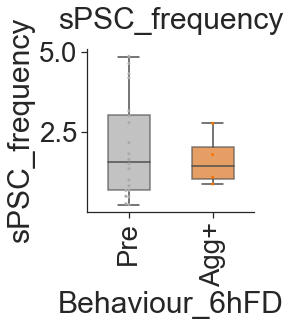

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8161651409276747


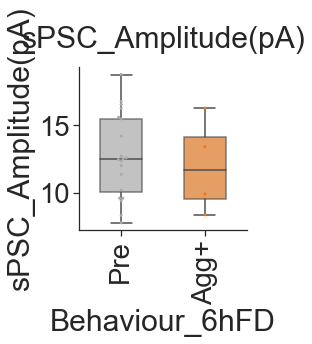

sPSCs_Rise time ('Pre', 'Agg+') 0.7224445223795837


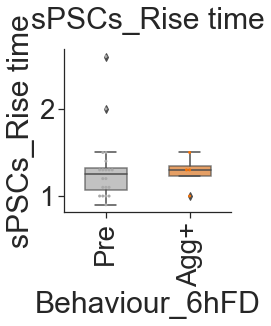

sPSCs (decay) ('Pre', 'Agg+') 1.0


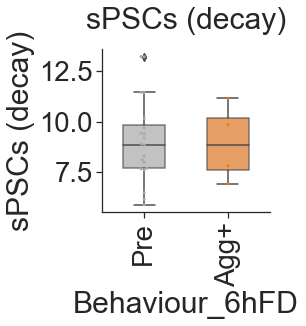

In [30]:
preprocess_plot(no_gal,'gal_minus')

## Ephys Gal+ vs Gal-

Cm(pF) 0.7323693239926063
Firing_freq_(Hz)_I0 0.6407646405225094
Instant_freq_(Hz) 0.6729139443059836
isi_(ms) 0.264690461240659
CaT 0.31129113670632236
Ih_at_-120mV 0.8027274535869496
AP_ampl 0.8859255231987084
AP_halfwidth 0.32548590700011526
AP_time_to_peak 0.2899382771639767
area(mV_ms) 0.37498685458791303
rheobase_at_-60mV_(pA) 0.4161053280322605
AHP_(mV) 0.80731274924489
Vm 0.029015379302906888
Input_Resistance 0.5478892229399508
sPSC_frequency 0.2622481192712615
sPSC_Amplitude(pA) 0.8336416545013177
sPSCs_Rise time 0.15061956182763336
sPSCs (decay) 0.1946103198988765
AC-I0 nan
AC_-60 nan


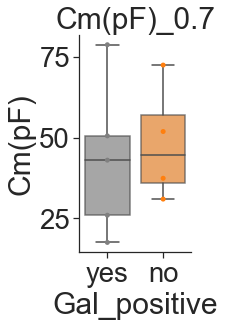

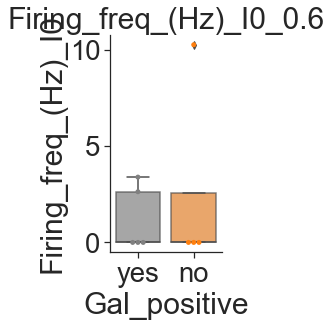

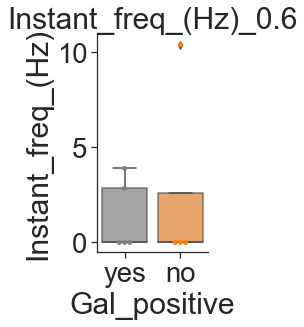

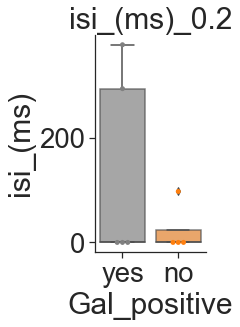

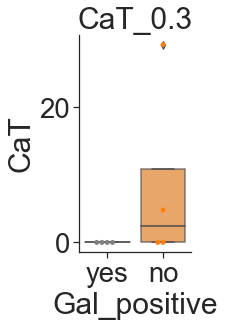

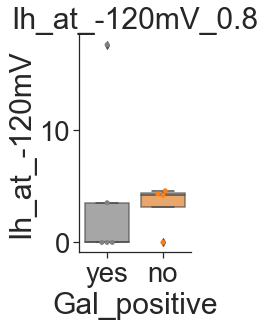

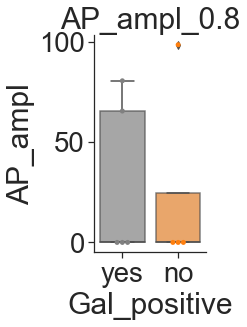

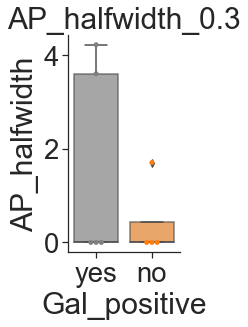

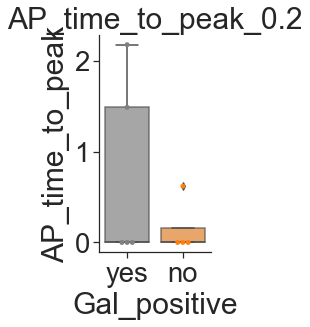

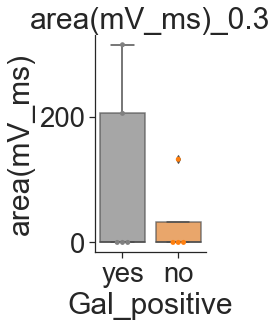

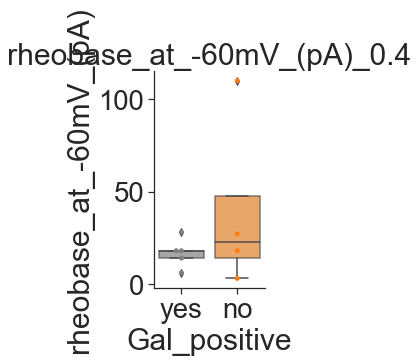

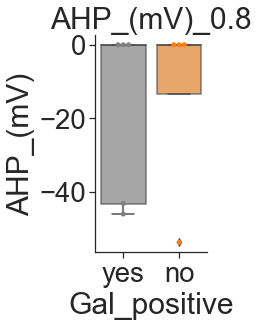

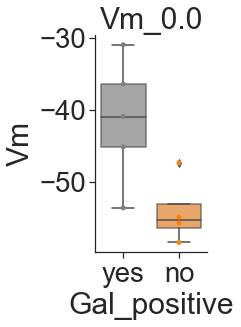

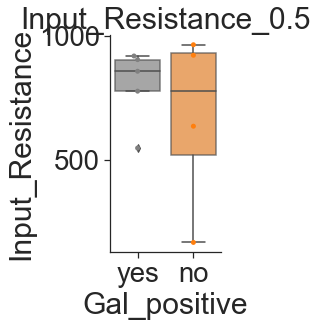

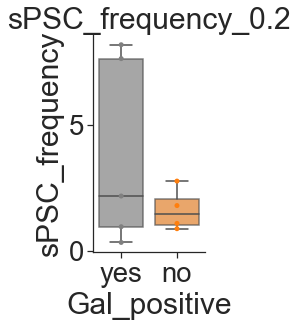

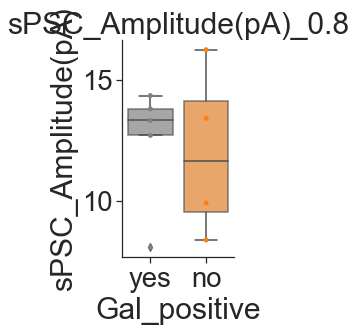

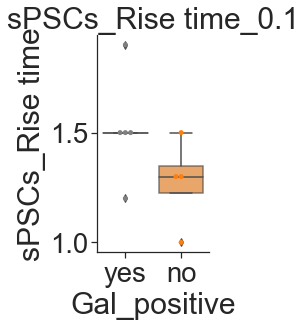

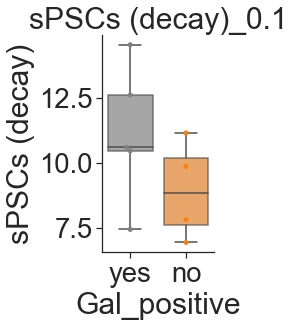

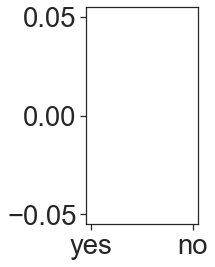

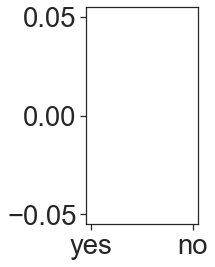

In [31]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
#         plt.show()
    except Exception:
        continue

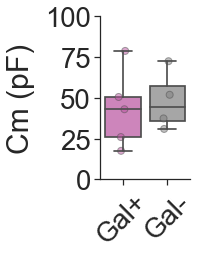

In [32]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

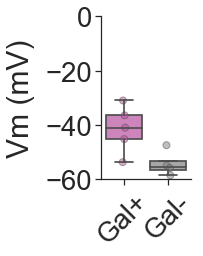

In [33]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

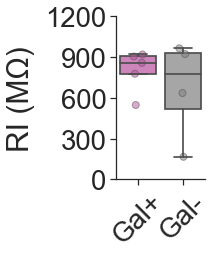

In [34]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1200)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

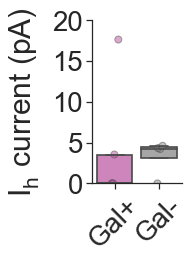

In [35]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ current (pA)', labelpad=10)

ax.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

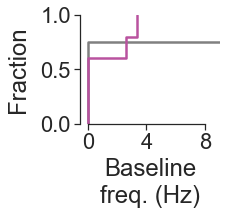

In [36]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [37]:
# ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
#    'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

In [38]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 'Firing_freq_(Hz)_I0': 'firing_freq'})
model = smf.ols('ih_current ~  I_zero_reclassified  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
I_zero_reclassified,81.779160,3.0,0.717139,0.542598
Residual,9198.852624,242.0,NaN,NaN


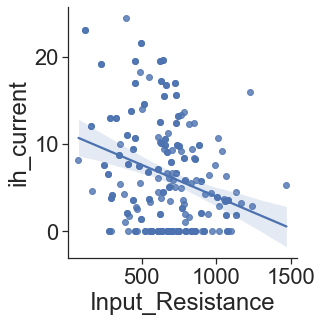

In [39]:
sns.lmplot(x = 'Input_Resistance', y = 'ih_current', data = trial, palette = ['darkgray', '#F97306', 'blue'])
          


No handles with labels found to put in legend.


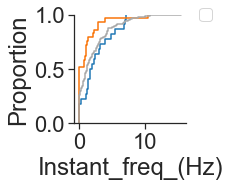

In [40]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']

fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## Proportion of silent neurons

I_zero          phasic  silent  tonic  tonic   All
Behaviour_6hFD                                    
Agg+                 6      15      8       0   29
Agg-                 4       4     14       0   22
Pre                 40      60    142       0  242
ZD7288               0      13      0       1   14
agrp_100             2       1      4       0    7
npy_10               0       0      4       0    4
npy_100              0       1      0       0    1
npy_antag            4       3      9       0   16
All                 56      97    181       1  335
8.820508007969327e-08


Text(0.5, 1.0, 'silent_prop')

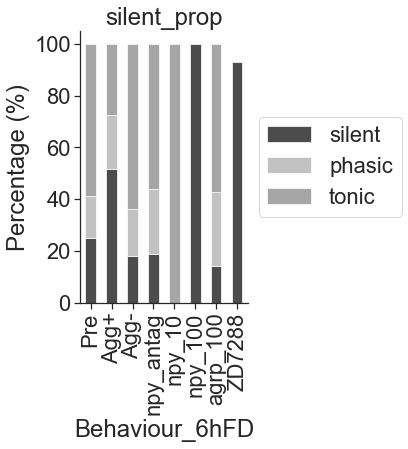

In [41]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10','npy_100', 'agrp_100', 'ZD7288']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')

In [42]:
silent_prop

I_zero,Behaviour_6hFD,silent,phasic,tonic
2,Pre,24.793388,16.528926,58.677686
0,Agg+,51.724138,20.689655,27.586207
1,Agg-,18.181818,18.181818,63.636364
7,npy_antag,18.750000,25.000000,56.250000
5,npy_10,0.000000,0.000000,100.000000
6,npy_100,100.000000,0.000000,0.000000
4,agrp_100,14.285714,28.571429,57.142857
3,ZD7288,92.857143,0.000000,0.000000


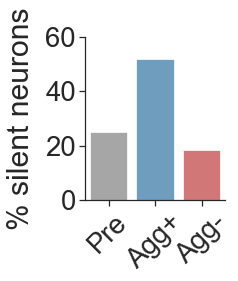

In [43]:
# % silent neurons
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'], palette = triple, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'Agg+', 'Agg-'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine(bottom=False)
# g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [44]:
# if % = 0, add small constant value of 2 to indicate that there is a column
silent_prop.loc[silent_prop['silent'] == 0, 'silent'] += 2

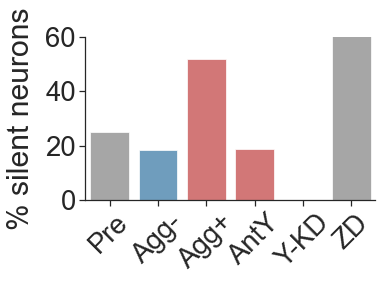

In [45]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg-', 'Agg+', 'npy_antag', 'npy_KD_dummy', 'ZD7288'],
                palette = sixtus, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels( ('Pre', 'Agg-', 'Agg+', 'AntY', 'Y-KD', 'ZD'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
dpi=300,bbox_inches='tight', transparent=True)

## Gal-specific silent proportion

I_zero        silent  tonic  All
Gal_positive                    
no                 3      1    4
yes                3      2    5
All                6      3    9
1.0


Text(0.5, 1.0, 'galanin_silent_prop')

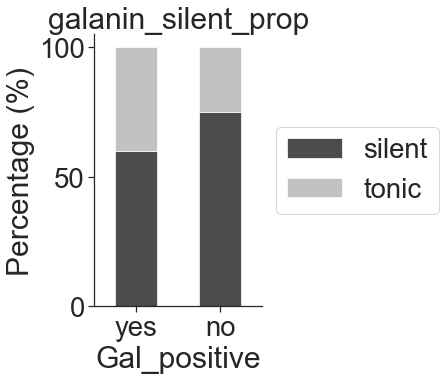

In [46]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
# plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

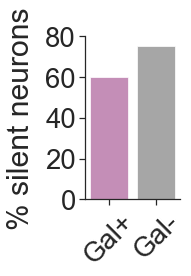

In [47]:
# % silent neurons
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Gal_positive", y="silent", order=['yes', 'no'], palette = dual, alpha=0.7)
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
plt.xlabel('')
plt.ylim(0,80)
g.yaxis.set_major_locator(plt.MaxNLocator(4)) 
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/silent.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1  12   16   29
Agg-            0  18    3   21
Pre             2  43   73  118
ZD7288          1   0   11   12
agrp_100        0   3    4    7
npy_10          0   2    2    4
npy_antag       0   5    5   10
All             4  83  114  201
0.0033492680246381776


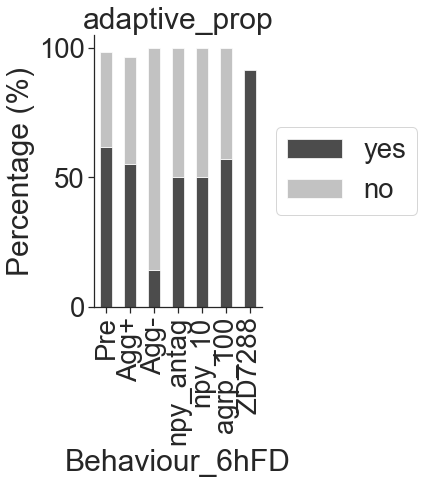

In [48]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10', 'agrp_100', 'ZD7288']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

Adaptive      no  yes  All
Gal_positive              
no             2    2    4
yes            3    2    5
All            5    4    9
1.0


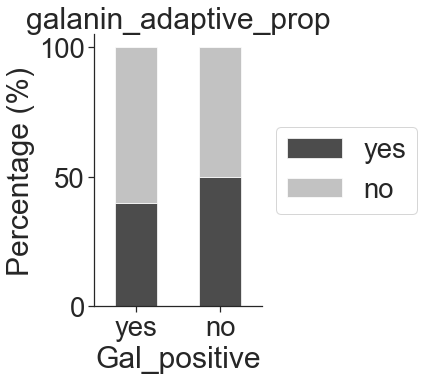

In [49]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

cat_categ         no  no   yes  yes   All
Behaviour_6hFD                           
Agg+              20    0    8     0   28
Agg-               9    1   11     1   22
Pre              111    0   85     0  196
ZD7288             8    0    4     0   12
agrp_100           7    0    0     0    7
agrp_100_paired    6    0    1     0    7
npy_10             3    1    0     0    4
npy_100            1    0    0     0    1
npy_antag         14    0    1     0   15
All              179    2  110     1  292
5.320626020014561e-07


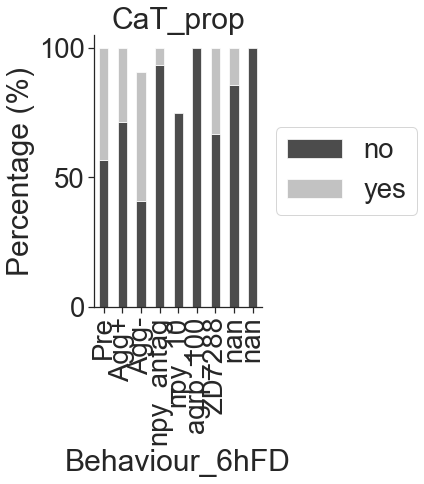

In [50]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             2    2    4
yes            4    1    5
All            6    3    9
0.8125242693153686


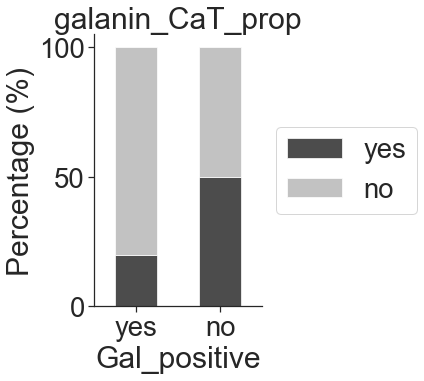

In [51]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

IH              no  yes  All
Behaviour_6hFD              
Pre             19   33   52
Agg+             5   10   15
Agg-             0    4    4
npy_antag        0    3    3
agrp_100         1    0    1
ZD7288          11    0   11
0.00037515638178292767


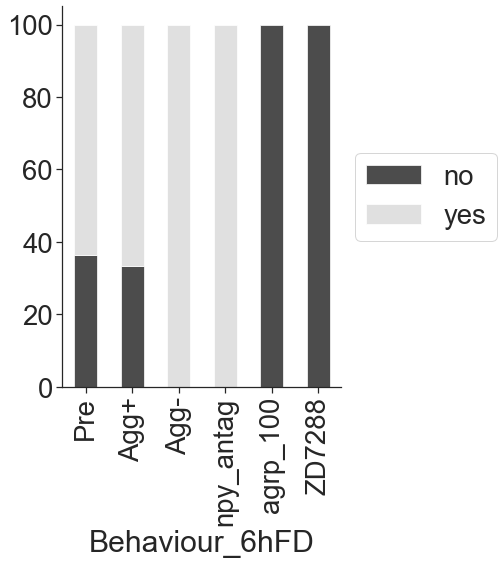

In [52]:
## prop of silent cells with/ without DB
DB_df = ephys[ephys.I_zero == 'silent']

DB_df.loc[(DB_df['Ih_at_-120mV'] == 0), 'IH']  = 'no'
DB_df.loc[(DB_df['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
DB_prop = pd.crosstab(DB_df['Behaviour_6hFD'], DB_df['IH'], margins = True).reset_index()
cols = ['Behaviour_6hFD', 'no', 'yes','All']
DB_prop = DB_prop[cols]
DB_prop['Behaviour_6hFD'] = pd.Categorical(DB_prop['Behaviour_6hFD'], cat)
DB_prop = DB_prop.sort_values(by = ['Behaviour_6hFD']).dropna()

plot_df = DB_prop.copy()

## chi square test
DB_prop.index = DB_prop.Behaviour_6hFD
DB_prop.drop(columns = ['Behaviour_6hFD'], inplace = True)
c, p, dof, expected = stats.chi2_contingency(DB_prop.iloc[:,:-1]) 
print(DB_prop)
print(p)

## plotting
plot_df.iloc[:, 1:5] = plot_df.iloc[:, 1:5].div(plot_df.All, axis = 0) *100
plot_df = plot_df.iloc[:, :-1]
plot_df.plot(
          x = 'Behaviour_6hFD', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['black','lightgray'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.ylabel('percentage of neurons with Calium T')

## IH prop

IH               no  yes  All
Behaviour_6hFD               
Agg+             11   17   28
Agg-              1   21   22
Pre              54  142  196
ZD7288           12    0   12
agrp_100          5    2    7
agrp_100_paired   1    6    7
npy_10            3    1    4
npy_100           1    0    1
npy_100_paired    2    1    3
npy_10_paired     0    5    5
npy_antag         3   12   15
All              93  207  300
7.821922616088661e-08


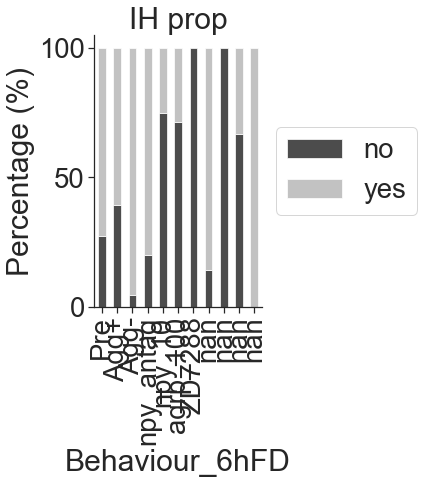

In [53]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic               10   39   49
silent               38   57   95
tonic                41  107  148
tonic                 2    4    6
All                  91  207  298
0.07308387046005711


Text(0.5, 0, '')

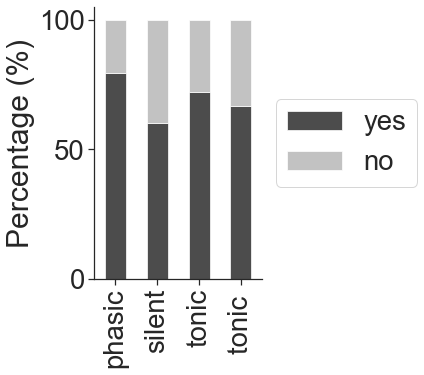

In [54]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis

In [182]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])

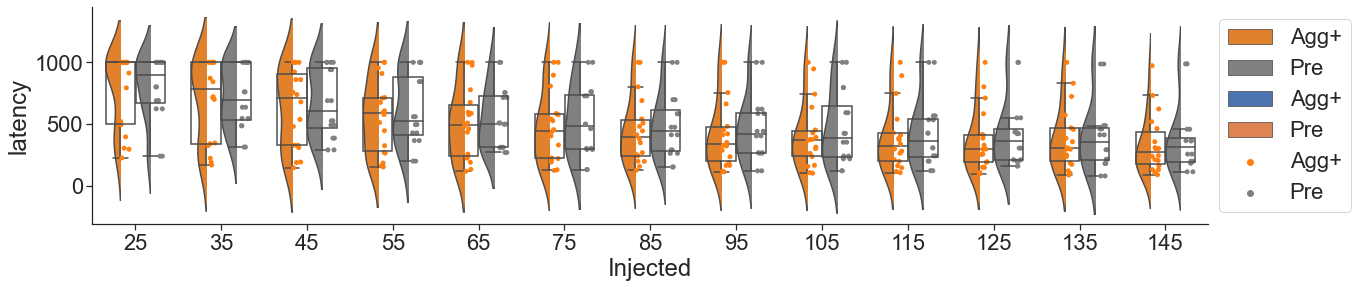

In [183]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [184]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),7.381683e+06,12.0,8.054835,1.237526e-13
C(Behaviour_6hFD),1.470714e+05,1.0,1.925798,1.659617e-01
C(Injected):C(Behaviour_6hFD),1.909296e+04,12.0,0.020834,1.000000e+00
Residual,3.176953e+07,416.0,NaN,NaN


In [58]:
# df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
# m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
# m_comp._results_table

## Ramp analysis as in Ammari et al.

In [ ]:
# code from Ammari et al.
# ramp = pd.read_excel('/Volumes/lab-kohlj/home/shared/projects/pregnancy_2021/sub_projects/MPOA-Gal_ephys/spike_data_excitability_Mar2023.xlsx')
# ramp_col=['#0000ff','#d7301f']
# ramp.head()

In [ ]:
# sns.set(rc={"figure.figsize": (3.5, 3)})
# sns.set(font_scale=2.5) 
# sns.set_style("ticks")

# x = sns.lineplot(y = 'spikes',x = 'ramp_current', data = ramp, hue='state', err_style='bars', ci=58, marker='o', lw=3, palette=ramp_col, alpha=0.5)

# x.set_ylabel('Evoked action\npotentials', labelpad=5)
# x.set_xlabel('Current (pA)', labelpad=5)
# x.xaxis.set_major_locator(plt.MaxNLocator(4))
# x.yaxis.set_major_locator(plt.MaxNLocator(5))
# x.legend_.remove()
# sns.despine()

In [ ]:
# two-way ANOVA
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
# model = ols('spikes ~ C(ramp_current) + C(state) + C(ramp_current):C(state)', data=ramp).fit()
# result = sm.stats.anova_lm(model, type=2)
# print(result)

In [ ]:
# from statsmodels.stats.multicomp import pairwise_tukeyhsd

# # Prepare data for Tukey HSD test
# endog = ramp['spikes']
# groups = pd.Series(ramp['state'])

# tukey_results = pairwise_tukeyhsd(
#     endog=endog,
#     groups=groups,
#     alpha=0.05
# )
# print(tukey_results)

In [185]:
df.to_csv('ramps_exported_JK.csv')

# Estrous cycle influence

I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   2       2      4    8
D                  19      18     60   97
E                   7      14     22   43
M                   6       8     17   31
P                   2      10     19   31
no VS               2       4     18   24
not taken           2       4      2    8
All                40      60    142  242
0.32195013681923096
I_zero         phasic  silent  tonic  All
estrous_stage                            
D                   2       5      3   10
E                   3       1      0    4
M                   2       7     10   19
P                   3       6      9   18
All                10      19     22   51
0.10402527942650186


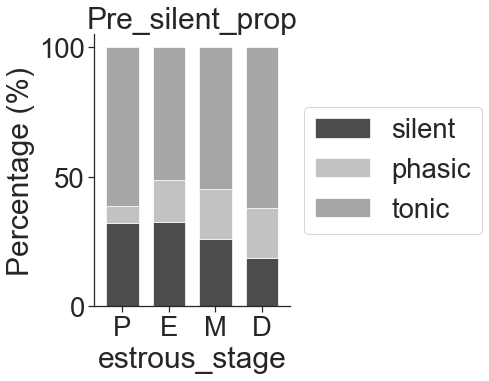

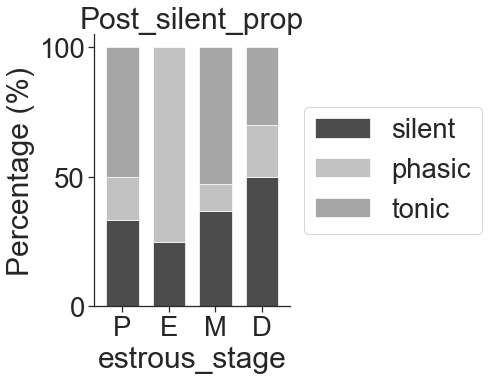

In [59]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   2       2      4    8
D                  19      18     60   97
E                   7      14     22   43
M                   6       8     17   31
P                   2      10     19   31
no VS               2       4     18   24
not taken           2       4      2    8
All                40      60    142  242
0.32195013681923096


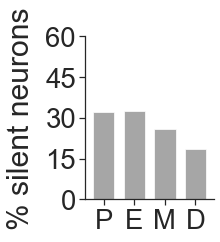

In [127]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg-','Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre']: #Post Pre
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', y = 'silent',
            kind = 'bar', 
            stacked = False,  
            mark_right = False,
            color = ['gray'],
            figsize = (2.3,3), alpha = 0.7, width = 0.7)
 
        
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('% silent neurons', labelpad=10)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xlabel(None)
    plt.ylim(0,60) 
    ax.get_legend().remove()
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_estrous_pre.pdf',
                dpi=300,bbox_inches='tight', transparent=True)

-0.18034782265031968 0.8196521773496803


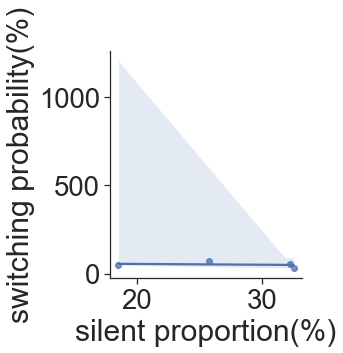

In [63]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

F_onewayResult(statistic=0.4328137741108785, pvalue=0.7300797086921997)


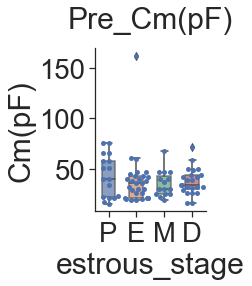

F_onewayResult(statistic=0.16419143036570535, pvalue=0.9203823289842754)


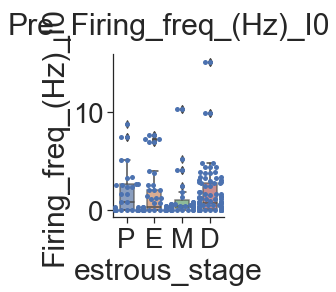

F_onewayResult(statistic=0.12925740334979846, pvalue=0.9426345590150569)


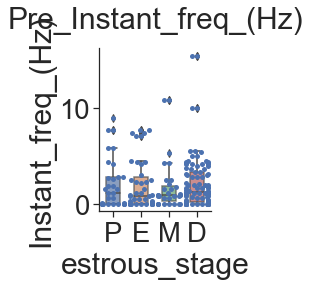

F_onewayResult(statistic=1.2774817893531523, pvalue=0.28329296020841255)


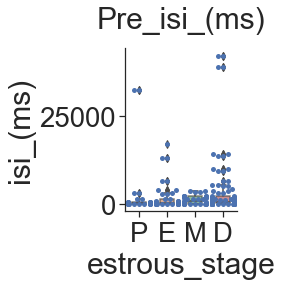

F_onewayResult(statistic=1.0513672946650927, pvalue=0.37130456278854557)


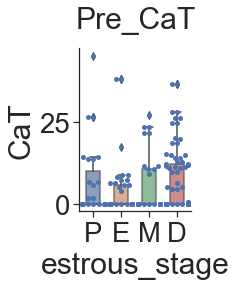

F_onewayResult(statistic=3.496561798954224, pvalue=0.016803282722984963)


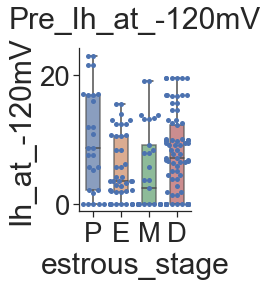

F_onewayResult(statistic=1.108879907974668, pvalue=0.3468291704323018)


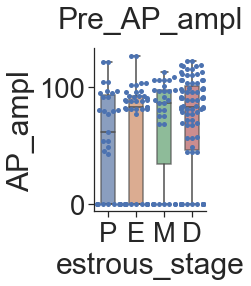

F_onewayResult(statistic=0.48869065638809406, pvalue=0.6905576403797412)


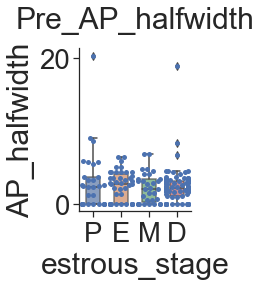

F_onewayResult(statistic=1.41581563601425, pvalue=0.23960995398410603)


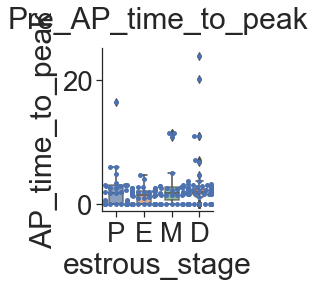

F_onewayResult(statistic=0.4114251423992339, pvalue=0.7449843408624836)


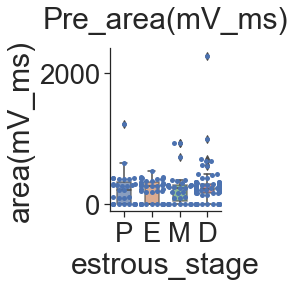

F_onewayResult(statistic=6.036369330877578, pvalue=0.00067723895268822)


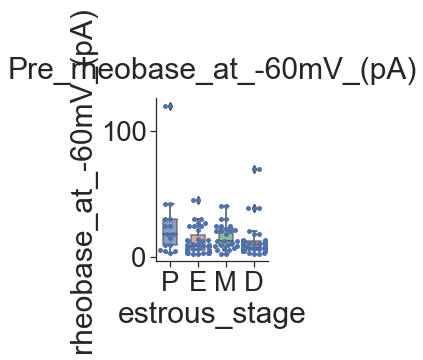

F_onewayResult(statistic=0.9158237373345464, pvalue=0.43441218449138197)


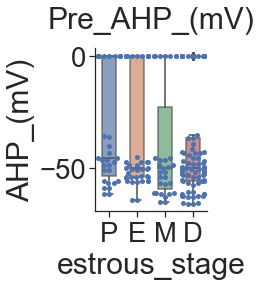

F_onewayResult(statistic=1.058407276515252, pvalue=0.36793188978376445)


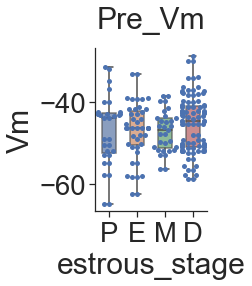

F_onewayResult(statistic=7.6427779774152125, pvalue=7.849442098541367e-05)


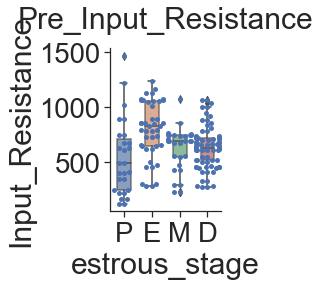

F_onewayResult(statistic=2.2883107395509414, pvalue=0.08458499824743701)


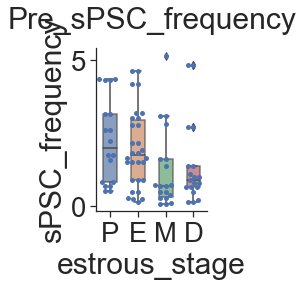

F_onewayResult(statistic=2.038060556374969, pvalue=0.11493941904586487)


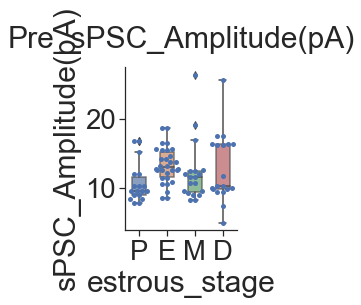

F_onewayResult(statistic=7.777574835109081, pvalue=0.0001984375516442889)


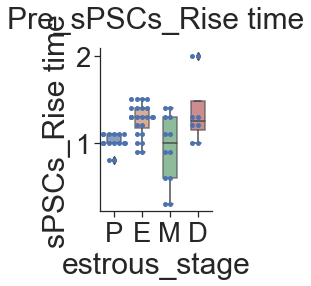

F_onewayResult(statistic=0.9926632582121734, pvalue=0.4032880968798811)


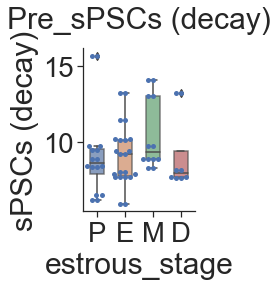

F_onewayResult(statistic=1.1688182850767281, pvalue=0.33363171282257625)
F_onewayResult(statistic=3.7208446444911565, pvalue=0.018871194740943308)


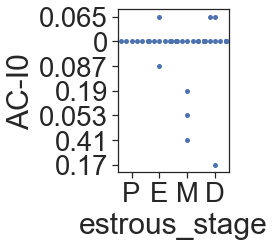

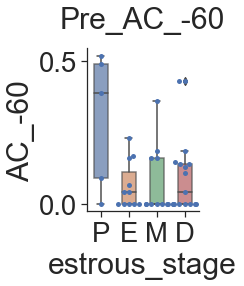

In [64]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for state in ['Pre']:
    for column in ls:
        state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        
        try:

            print(stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna()))
            


            fig,ax = plt.subplots(figsize = (2,3))
            sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 1)
            sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5)
            sns.despine()
            plt.title(f'{state}_{column}', pad = 20)
            
            plt.show()
        except Exception:
            continue

cat_categ       no  yes  All
estrous_stage               
?                2    6    8
D               42   39   81
E               29   14   43
M               19   10   29
P               15   12   27
not taken        4    4    8
All            111   85  196
0.2099431992982078
cat_categ estrous_stage         no        yes
4                     P  55.555556  44.444444
2                     E  67.441860  32.558140
3                     M  65.517241  34.482759
1                     D  51.851852  48.148148


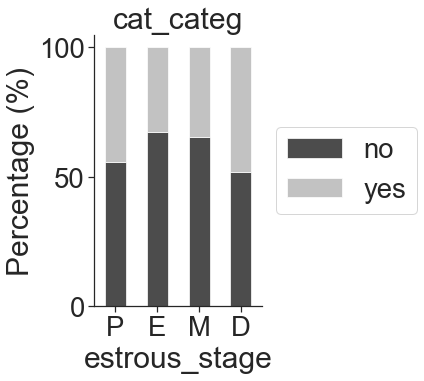

-0.0641323091459038 0.9358676908540962


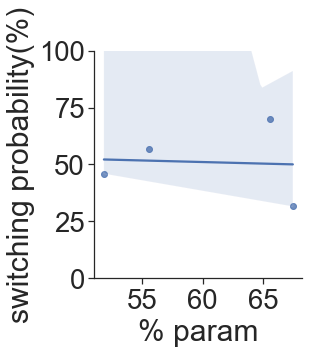

IH             no  yes  All
estrous_stage              
?               0    8    8
D              21   60   81
E              10   33   43
M              14   15   29
P               5   22   27
not taken       4    4    8
All            54  142  196
0.024230628517218786
IH estrous_stage         no        yes
4              P  18.518519  81.481481
2              E  23.255814  76.744186
3              M  48.275862  51.724138
1              D  25.925926  74.074074


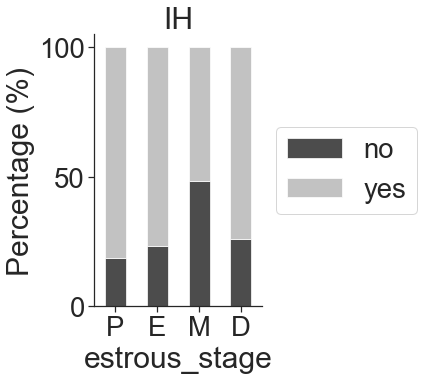

0.6720686747746435 0.3279313252253565


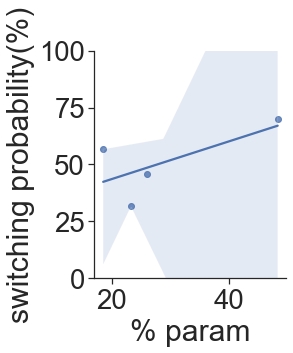

Adaptive       ?  no  yes  All
estrous_stage                 
?              0   0    2    2
D              0  19   23   42
E              0   7   24   31
M              0  13   13   26
P              2   4   11   17
All            2  43   73  118
0.010856272015613667
Adaptive estrous_stage         no        yes
4                    P  23.529412  64.705882
2                    E  22.580645  77.419355
3                    M  50.000000  50.000000
1                    D  45.238095  54.761905


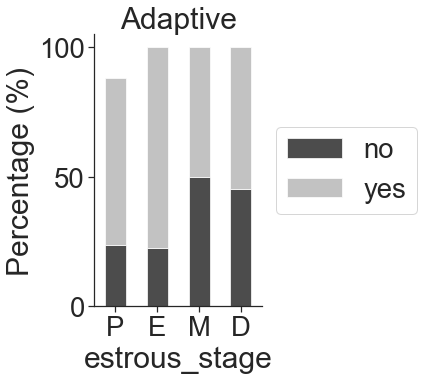

0.5850954623371792 0.41490453766282076


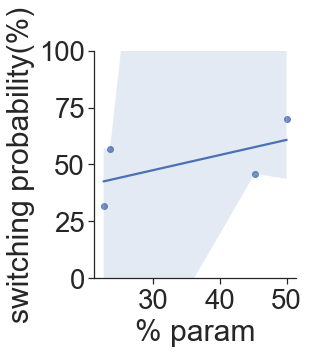

In [65]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr)
    plt.ylim([0, 100])
    plt.xlabel('% param')
    plt.ylabel('switching probability(%)')
    plt.show()

## Individual plots JK

### Pre FD

In [128]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

Number of neurons/mice in each group

In [198]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 31 from 8 mice
Number of E neurons: 43 from 8 mice
Number of M neurons: 31 from 7 mice
Number of D neurons: 97 from 7 mice


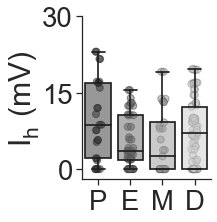

In [129]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

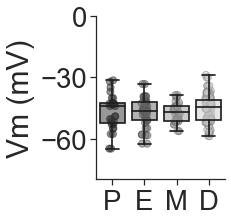

In [130]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

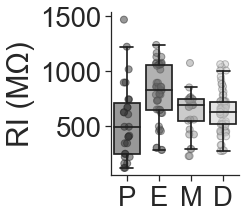

In [131]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

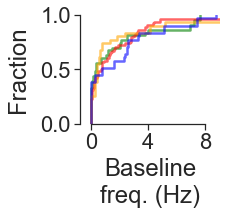

In [171]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

### Post FD (Agg+ and Agg- pooled)

In [199]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

Number of neurons/mice in each group

In [200]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 19 from 3 mice
Number of D neurons: 8 from 2 mice


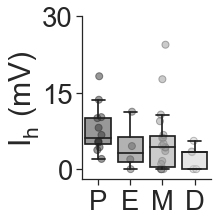

In [133]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

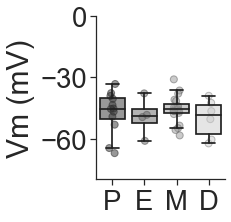

In [134]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

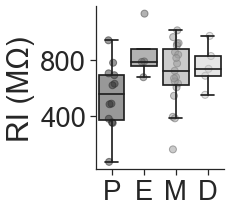

In [135]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

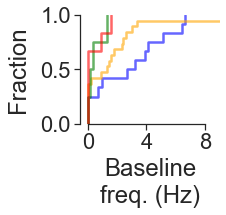

In [172]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

### Post FD (only Agg+)

In [173]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post_agg = ephys[(ephys['Behaviour_6hFD'] == 'Agg+')]

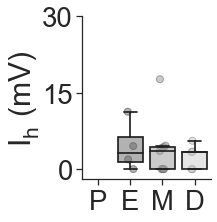

In [174]:
# Ih - Post Agg+ only
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post_agg, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post_agg, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_estrous_post_agg.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

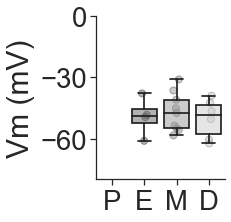

In [175]:
# Membrane voltage - estrous Post Agg+ only

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post_agg, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post_agg, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_post_agg.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

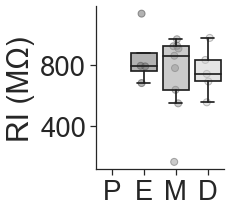

In [176]:
# Input resistance - estrous Post Agg+ only

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post_agg, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post_agg, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_post_agg.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

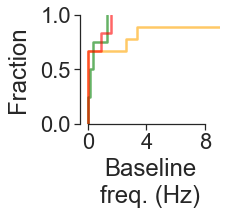

In [177]:
# Firing frequency - estrous Post Agg+ only

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2_agg = ephys_post_agg[ephys_post_agg['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2_agg, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_post_agg.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# NPY administration

In [136]:
def pairline_plot(y, data):
    plt.subplots(figsize = (1.5,2))
    sns.lineplot(x = 'condition', y = y, hue = 'cell_id',data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.swarmplot(x = 'condition', y = y ,data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.boxplot(x = 'condition', y = y,data = data, palette = ['Tab:red'],boxprops=dict(alpha=.5), width = 0.5)
    ax = plt.gca()
    ax.get_legend().remove()
    sns.despine()
    plt.xticks(rotation = 90)
    plt.xlabel('')
    plt.show()

def sub_datset(data):

    vm = data.melt(id_vars=['cell_id'], value_vars=['Vm_control', 'Vm_drug'], var_name='condition', value_name='Vm')
    ir = data.melt(id_vars=['cell_id'], value_vars=['IR_control', 'IR_drug'], var_name='condition', value_name='IR')
    ih = data.melt(id_vars=['cell_id'], value_vars=['Ih_control', 'Ih_drug'], var_name='condition', value_name='Ih')
    fr = data.melt(id_vars=['cell_id'], value_vars=['firing_freq_control', 'firing_freq_drug'], var_name='condition', value_name='firing_freq')

    return [vm, ir, ih, fr]
    

100npy


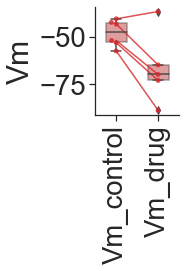

100npy


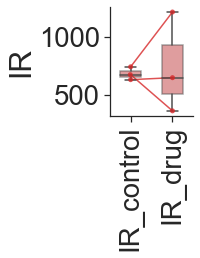

100npy


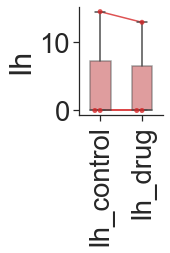

100npy


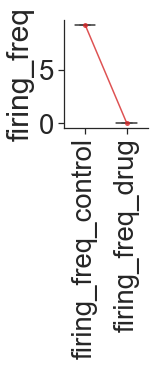

10npy


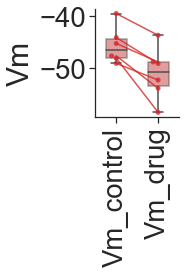

10npy


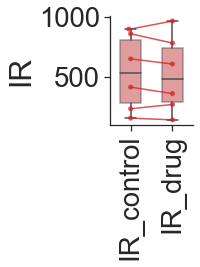

10npy


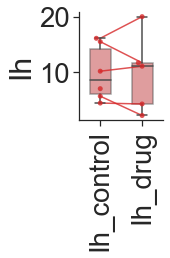

10npy


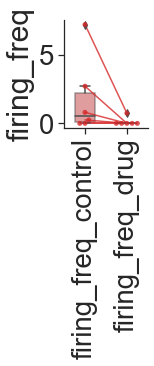

In [137]:
df = pd.read_csv('pharmacology.csv')
df['drug'] = df.conc_nM.astype(str) + df.identity


for drug in df.drug.unique()[:-1]:
    drug_df = df[df.drug == drug]
    df_list = sub_datset(drug_df)

    for subdata in df_list:
        
        subdata  = subdata.dropna()
        if len(subdata.condition.unique()) <2:
            continue
        else:
            print(drug)
            pairline_plot(str(subdata.columns[2]), subdata)

## new plots JK

In [138]:
#NPY to Pre --> mimics Agg+, i.e., decrease in Ih / increased Ri / increased % silent?

In [56]:
# reload data and convert all instances of NPY application to 'npy'
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace([ 'npy_10'], 'npy')

Number of neurons in each group

In [57]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 247 from 27 mice
Number of NPY neurons: 10 from 3 mice


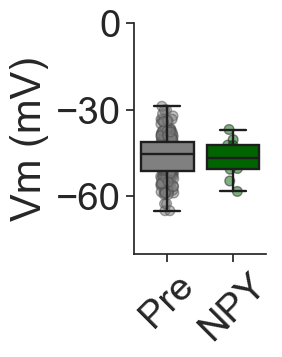

In [58]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

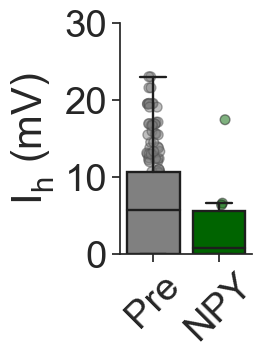

In [59]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

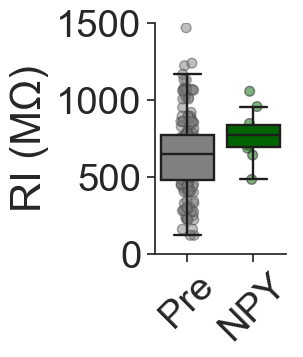

In [60]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [61]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 40      60    143  243
npy                  1       1      8   10
All                 41      61    151  253
0.4010720168442149


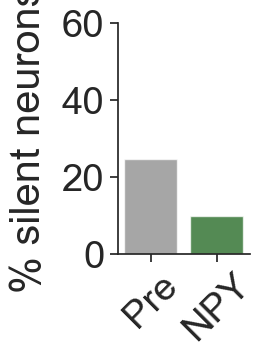

In [62]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [63]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy')]

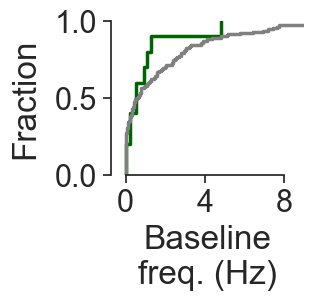

In [64]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# AgRP administration

In [65]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

In [66]:
# reload data and convert all instances of AgRP application to 'agrp'
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace([ 'agrp_100'], 'agrp')

Number of neurons in each group

In [67]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 247 from 27 mice
Number of AgRP neurons: 15 from 5 mice


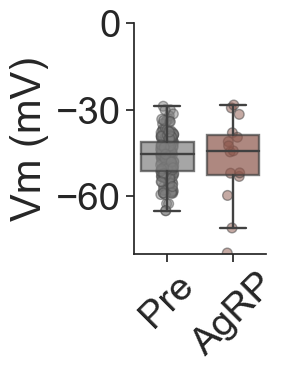

In [68]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp, boxprops=dict(alpha=0.7))
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

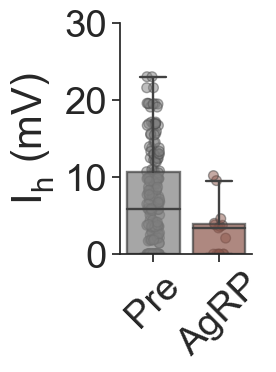

In [69]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp, boxprops=dict(alpha=0.7))
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

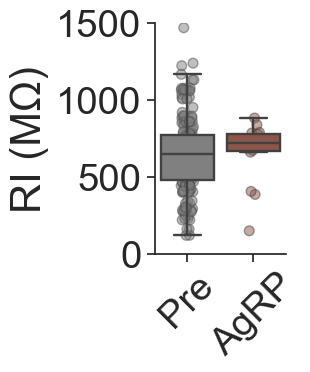

In [70]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [71]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  tonic   All
Behaviour_6hFD                                    
Pre                 40      60    143       0  243
agrp                 2       5      3       5   15
All                 42      65    146       5  258
2.269344380312796e-18


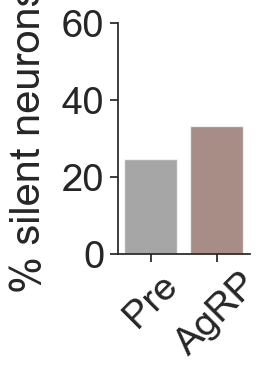

In [72]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [73]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp')]

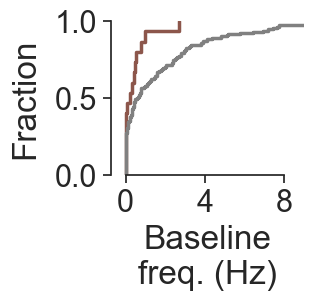

In [74]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)